In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader as pdr
#important
from datetime import datetime
%matplotlib inline
sns.set_theme()

In [2]:
df_tesla = pd.read_csv("dataset/MacroTrends_Data_Download_TSLA.csv")

In [3]:
df_tesla.head()

,date,open,high,low,close,volume
0,6/29/2010,1.2667,1.6667,1.1694,1.5927,18783750
1,6/30/2010,1.7194,2.0280,1.5534,1.5887,17194825
2,7/1/2010,1.6667,1.7280,1.3513,1.4640,8229863
3,7/2/2010,1.5333,1.5400,1.2473,1.2800,5141807
4,7/6/2010,1.3333,1.3333,1.0553,1.0740,6879296


In [4]:
df_tesla['date'] = pd.to_datetime(df_tesla['date'])

In [5]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3733 entries, 0 to 3732
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3733 non-null   datetime64[ns]
 1   open    3733 non-null   float64       
 2   high    3733 non-null   float64       
 3   low     3733 non-null   float64       
 4   close   3733 non-null   float64       
 5   volume  3733 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 175.1 KB


In [6]:
df_tesla.set_index('date', inplace = True)

<Axes: xlabel='date'>

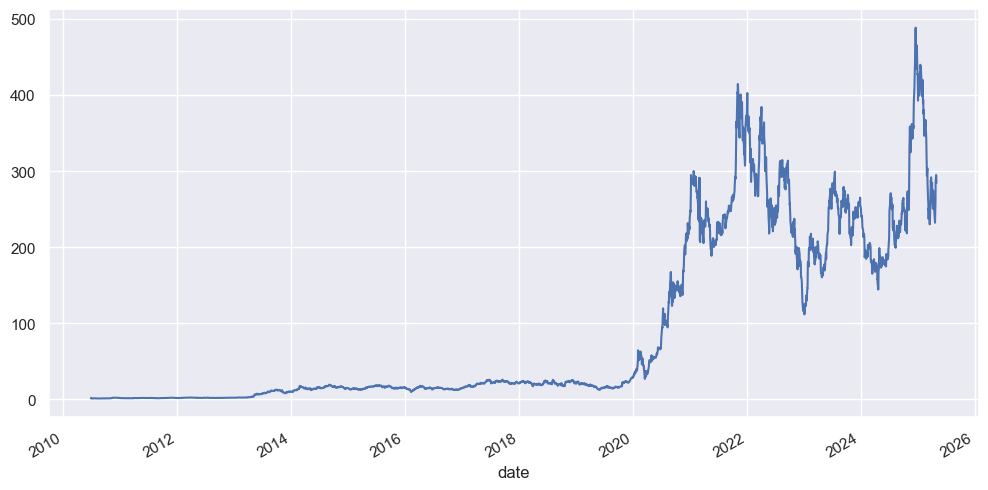

In [15]:
df_tesla['high'].plot(figsize=(12, 6))

<Axes: xlabel='date'>

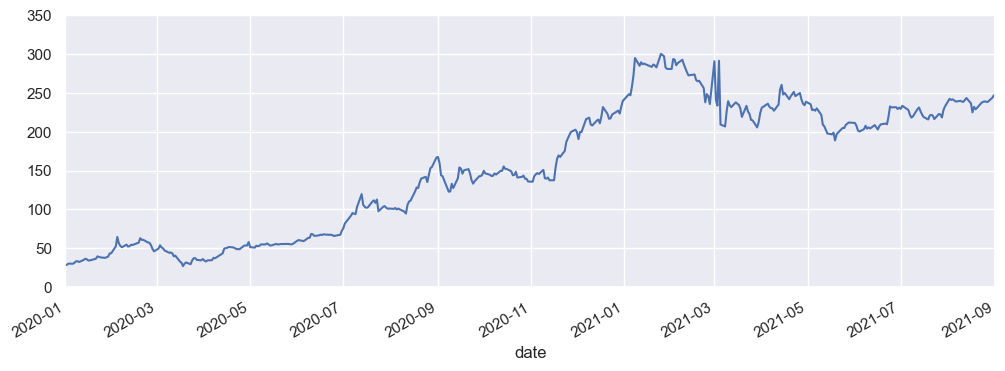

In [8]:
df_tesla['high'].plot(xlim = ['2020-01-01', '2021-09-01'], ylim=[0, 350], figsize=(12,4))

<Axes: xlabel='date'>

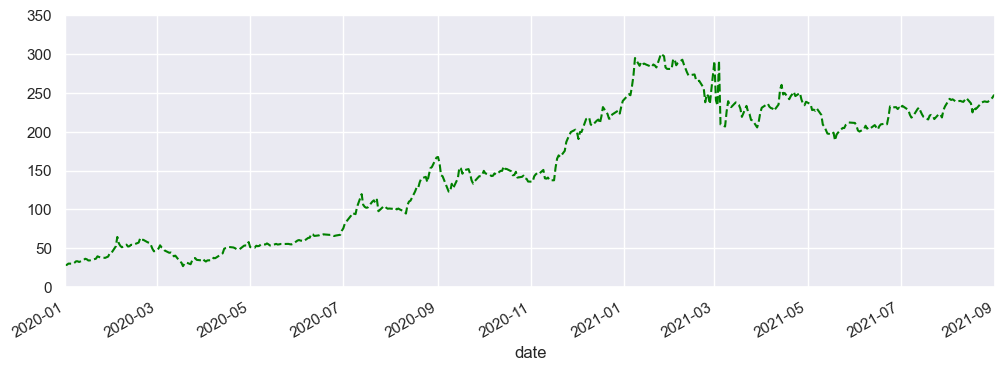

In [16]:
df_tesla['high'].plot(xlim = ['2020-01-01', '2021-09-01'], ylim=[0, 350], figsize=(12,4), ls='--', c = 'green')

In [10]:
df_tesla.loc['2020-01-01' : '2021-09-01']

,open,high,low,close,volume
date,,,,,
2020-01-02,28.3000,28.7130,28.1140,28.6840,9558386
2020-01-03,29.3667,30.2667,29.1280,29.5340,17794698
2020-01-06,29.3647,30.1040,29.3334,30.1027,10157513
2020-01-07,30.7600,31.4420,30.2237,31.2707,18209163
2020-01-08,31.5800,33.2326,31.2153,32.8093,31199352
...,...,...,...,...,...
2021-08-26,236.1030,238.4670,232.5400,233.7200,13214290
2021-08-27,235.0000,238.3330,234.0330,237.3070,13833762
2021-08-30,238.2380,243.6670,237.5770,243.6370,18604223


In [11]:
index = df_tesla.loc['2020-01-01' : '2021-09-01'].index
index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='date', length=421, freq=None)

In [12]:
share_open = df_tesla.loc['2020-01-01' : '2021-09-01']['open']

In [13]:
share_open.head()

date
2020-01-02    28.3000
2020-01-03    29.3667
2020-01-06    29.3647
2020-01-07    30.7600
2020-01-08    31.5800
Name: open, dtype: float64

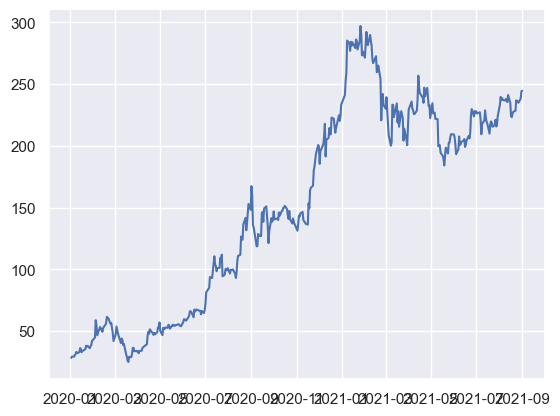

In [20]:
fig, ax = plt.subplots()
ax.plot(index, share_open)

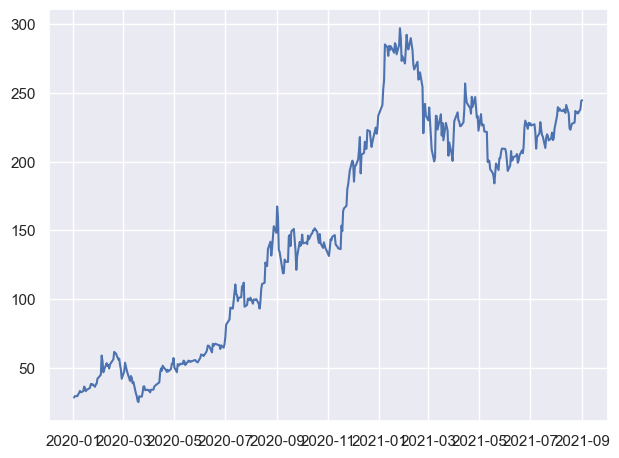

In [31]:
fig, ax = plt.subplots()
# similar to padding
plt.tight_layout()
ax.plot(index, share_open)

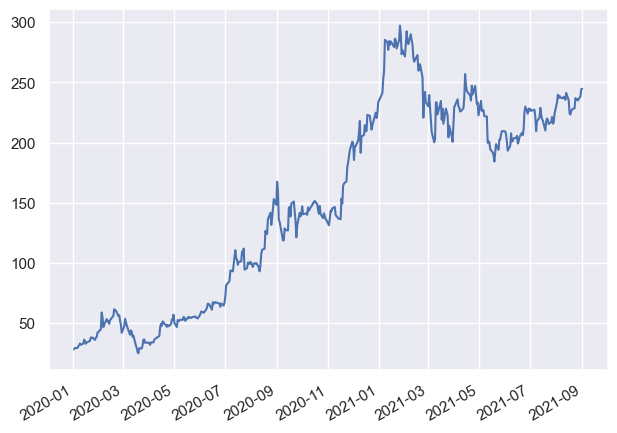

In [ ]:
fig, ax = plt.subplots( )
plt.tight_layout()
# Preventing overlapping
fig.autofmt_xdate()
ax.plot(index, share_open)

In [36]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3733 entries, 2010-06-29 to 2025-04-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    3733 non-null   float64
 1   high    3733 non-null   float64
 2   low     3733 non-null   float64
 3   close   3733 non-null   float64
 4   volume  3733 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 304.0 KB


## Time Resampling

In [43]:
df_tesla.head()

,open,high,low,close,volume
date,,,,,
2010-06-29,1.2667,1.6667,1.1694,1.5927,18783750
2010-06-30,1.7194,2.0280,1.5534,1.5887,17194825
2010-07-01,1.6667,1.7280,1.3513,1.4640,8229863
2010-07-02,1.5333,1.5400,1.2473,1.2800,5141807
2010-07-06,1.3333,1.3333,1.0553,1.0740,6879296


In [49]:
df_tesla.resample(rule = 'A').max()

C:\Users\hassa\AppData\Local\Temp\ipykernel_14780\1992919970.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_tesla.resample(rule = 'A').max()


,open,high,low,close,volume
date,,,,,
2010-12-31,2.3913,2.4280,2.3167,2.3647,18783750
2011-12-31,2.3086,2.3334,2.2688,2.3293,11522339
2012-12-31,2.5460,2.6633,2.4740,2.5340,5684952
2013-12-31,12.9307,12.9666,12.5580,12.8913,37163632
2014-12-31,19.1780,19.4280,18.6933,19.0693,32796919
2015-12-31,18.6797,19.1100,18.4200,18.8173,15649563
2016-12-31,17.7634,17.9560,16.9674,17.6947,23742479
2017-12-31,25.7793,25.9740,25.2896,25.6667,19791457
2018-12-31,25.0000,25.8307,24.4746,25.3047,33649610


C:\Users\hassa\AppData\Local\Temp\ipykernel_14780\1690957118.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_tesla.resample(rule = 'A').max()['open'].plot()


<Axes: xlabel='date'>

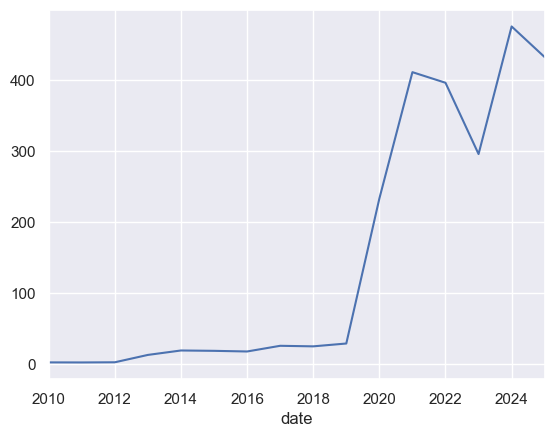

In [ ]:

df_tesla.resample(rule = 'A').max()['open'].plot()

<Axes: xlabel='date'>

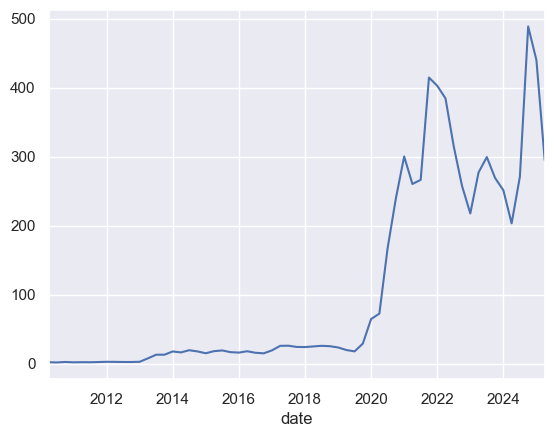

In [ ]:
# Quaterly start frequency
## https://
df_tesla.resample(rule = 'QS').max()['high'].plot()

C:\Users\hassa\AppData\Local\Temp\ipykernel_14780\1010655176.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_tesla.loc['2020':'2021'].resample(rule = 'M').max()['high'].plot(kind = 'bar', figsize=(15, 6))


<Axes: xlabel='date'>

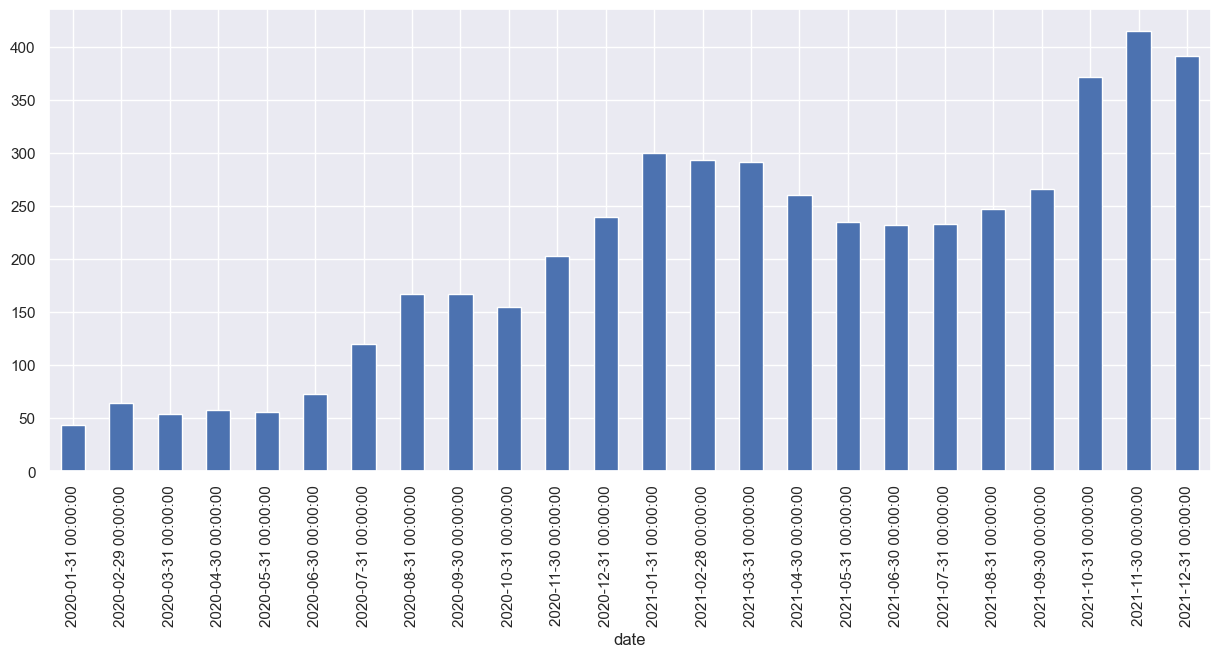

In [62]:
df_tesla.loc['2020':'2021'].resample(rule = 'M').max()['high'].plot(kind = 'bar', figsize=(15, 6))